In [1]:
# importing libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from datetime import datetime, timedelta

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

pd.set_option('display.max_columns', None)

In [2]:
# Reading the dataset
df = pd.read_csv("../data/Afficionado Coffee Roasters.xlsx - Transactions (2).csv")

df.head

<bound method NDFrame.head of         transaction_id  year transaction_time  transaction_qty  store_id  \
0                    1  2025          7:06:11                2         5   
1                    2  2025          7:08:56                2         5   
2                    3  2025          7:14:04                2         5   
3                    4  2025          7:20:24                1         5   
4                    5  2025          7:22:41                2         5   
...                ...   ...              ...              ...       ...   
149111          149452  2025         20:18:41                2         8   
149112          149453  2025         20:25:10                2         8   
149113          149454  2025         20:31:34                1         8   
149114          149455  2025         20:57:19                1         8   
149115          149456  2025         20:57:19                2         8   

         store_location  product_id  unit_price    produc

In [3]:
# Display the first few rows of the dataframe
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [4]:
## Display the last few rows of the dataframe
df.tail()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
149111,149452,2025,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2025,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2025,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2025,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino
149115,149456,2025,20:57:19,2,8,Hell's Kitchen,64,0.80,Flavours,Regular syrup,Hazelnut syrup


In [5]:
# Display the number of rows and columns in the dataframe
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()


Rows : 149116
Columns : 11
<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  str    
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  str    
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  str    
 9   product_type      149116 non-null  str    
 10  product_detail    149116 non-null  str    
dtypes: float64(1), int64(5), str(5)
memory usage: 20.9 MB


In [6]:
# Display summary statistics for all columns
df.describe(include='all')

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
count,149116.000000,149116.0,149116,149116.000000,149116.000000,149116,149116.000000,149116.000000,149116,149116,149116
unique,NaN,NaN,25762,NaN,NaN,3,NaN,NaN,9,29,80
top,NaN,NaN,9:31:15,NaN,NaN,Hell's Kitchen,NaN,NaN,Coffee,Brewed Chai tea,Chocolate Croissant
freq,NaN,NaN,41,NaN,NaN,50735,NaN,NaN,58416,17183,3076
mean,74737.371872,2025.0,NaN,1.438276,5.342063,NaN,47.918607,3.382219,NaN,NaN,NaN
std,43153.600016,0.0,NaN,0.542509,2.074241,NaN,17.930020,2.658723,NaN,NaN,NaN
min,1.000000,2025.0,NaN,1.000000,3.000000,NaN,1.000000,0.800000,NaN,NaN,NaN
25%,37335.750000,2025.0,NaN,1.000000,3.000000,NaN,33.000000,2.500000,NaN,NaN,NaN
50%,74727.500000,2025.0,NaN,1.000000,5.000000,NaN,47.000000,3.000000,NaN,NaN,NaN
75%,112094.250000,2025.0,NaN,2.000000,8.000000,NaN,60.000000,3.750000,NaN,NaN,NaN


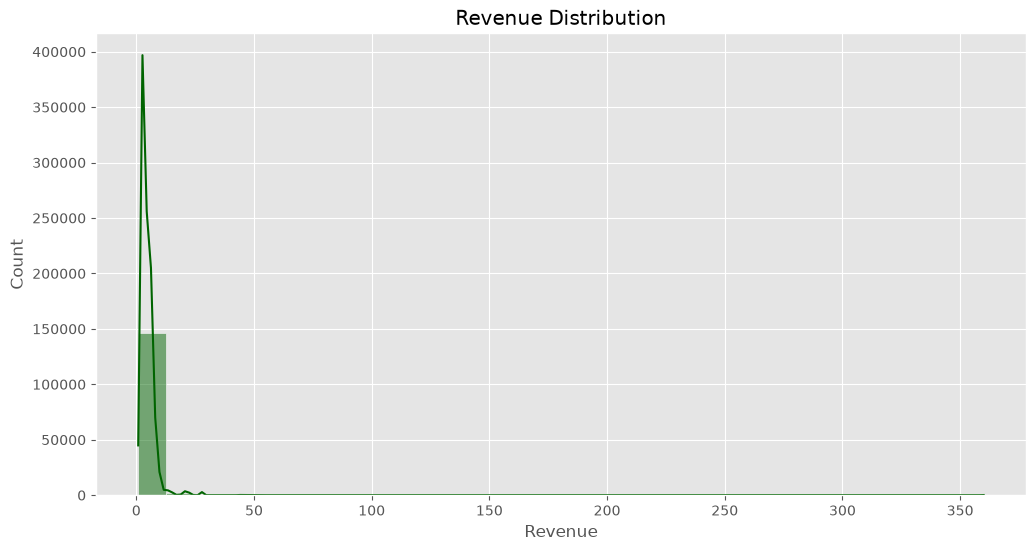

In [7]:
df["Revenue"] = df["transaction_qty"] * df["unit_price"]

plt.figure(figsize=(12,6))

sns.histplot(
    df["Revenue"],
    bins=30,
    kde=True,
    color="darkgreen"
)

plt.title("Revenue Distribution")
plt.show()

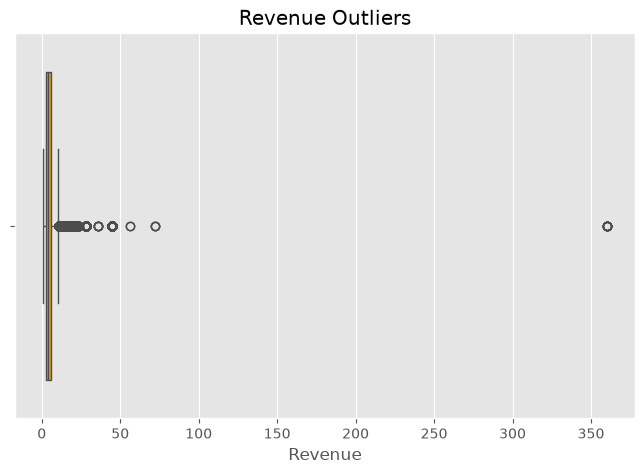

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Revenue"],
    color="orange"
)

plt.title("Revenue Outliers")
plt.show()

In [9]:
top_products = (
    df.groupby("product_detail")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

product_detail
Sustainably Grown Organic Lg    21151.75
Dark chocolate Lg               21006.00
Latte Rg                        19112.25
Cappuccino Lg                   17641.75
Morning Sunrise Chai Lg         17384.00
Latte                           17257.50
Jamaican Coffee River Lg        16481.25
Sustainably Grown Organic Rg    16233.75
Cappuccino                      15997.50
Brazilian Lg                    15109.50
Name: Revenue, dtype: float64

C:\Users\devan\AppData\Local\Temp\ipykernel_15336\1456922899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


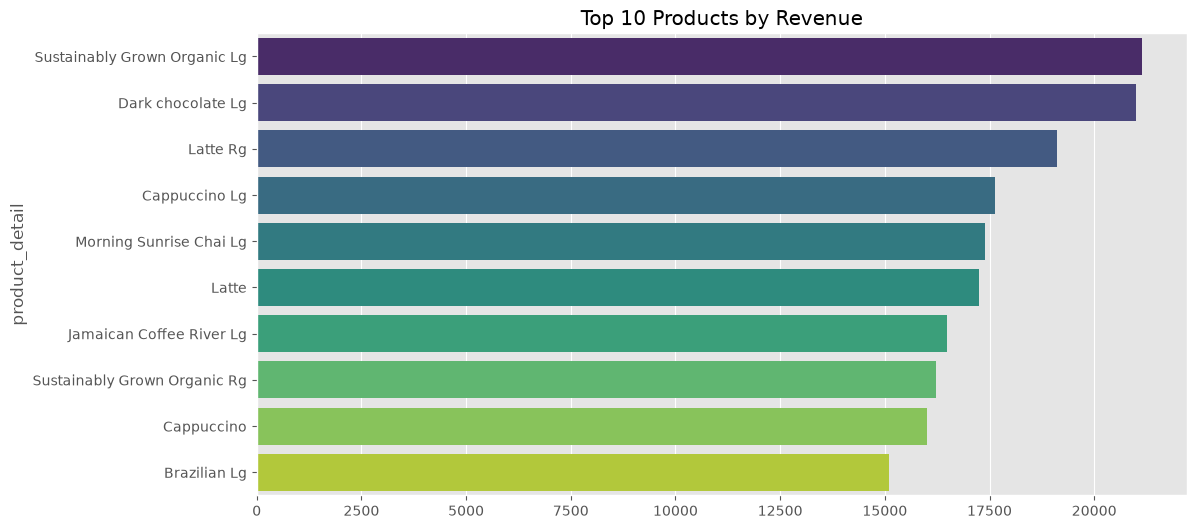

In [10]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette="viridis"
)

plt.title("Top 10 Products by Revenue")

plt.show()

In [11]:
popular_products = (
    df.groupby("product_detail")["transaction_qty"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
popular_products

product_detail
Earl Grey Rg                   4708
Dark chocolate Lg              4668
Morning Sunrise Chai Rg        4643
Latte                          4602
Peppermint Rg                  4564
Columbian Medium Roast Rg      4547
Traditional Blend Chai Rg      4512
Latte Rg                       4497
Our Old Time Diner Blend Sm    4484
Serenity Green Tea Rg          4477
Name: transaction_qty, dtype: int64

C:\Users\devan\AppData\Local\Temp\ipykernel_15336\3963378128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


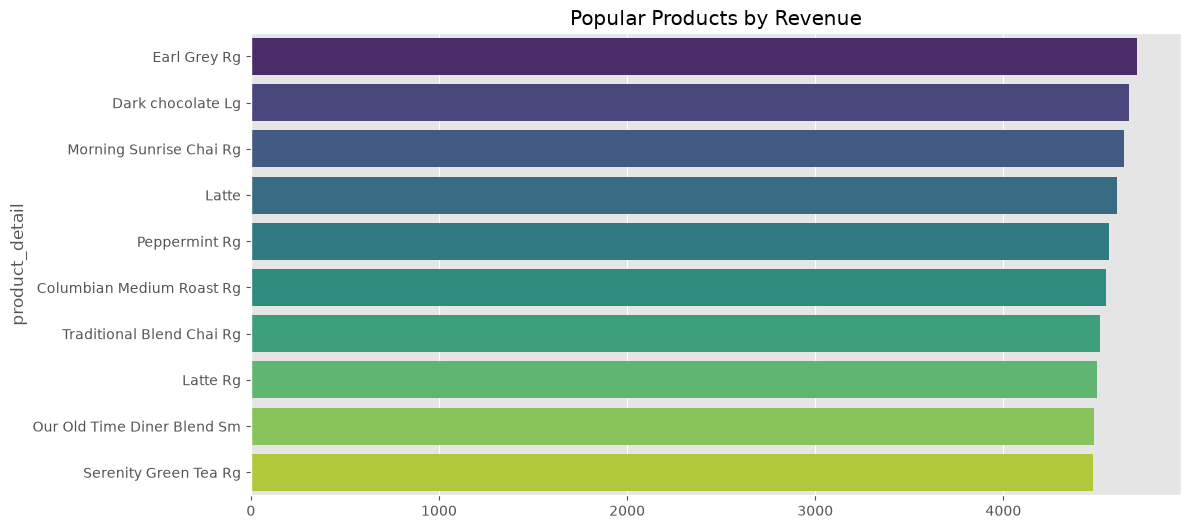

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=popular_products.values,
    y=popular_products.index,
    palette="viridis"
)

plt.title("Popular Products by Revenue")
plt.show()

In [13]:
bottom_products = (
    df.groupby("product_detail")["Revenue"]
      .sum()
      .sort_values()
      .head(10)
)
bottom_products

product_detail
Dark chocolate                   755.20
Earl Grey                       1270.90
Spicy Eye Opener Chai           1335.90
Guatemalan Sustainably Grown    1340.00
Lemon Grass                     1360.40
Peppermint                      1369.35
Traditional Blend Chai          1369.35
English Breakfast               1440.95
Serenity Green Tea              1470.75
Morning Sunrise Chai            1596.00
Name: Revenue, dtype: float64

C:\Users\devan\AppData\Local\Temp\ipykernel_15336\1921146315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


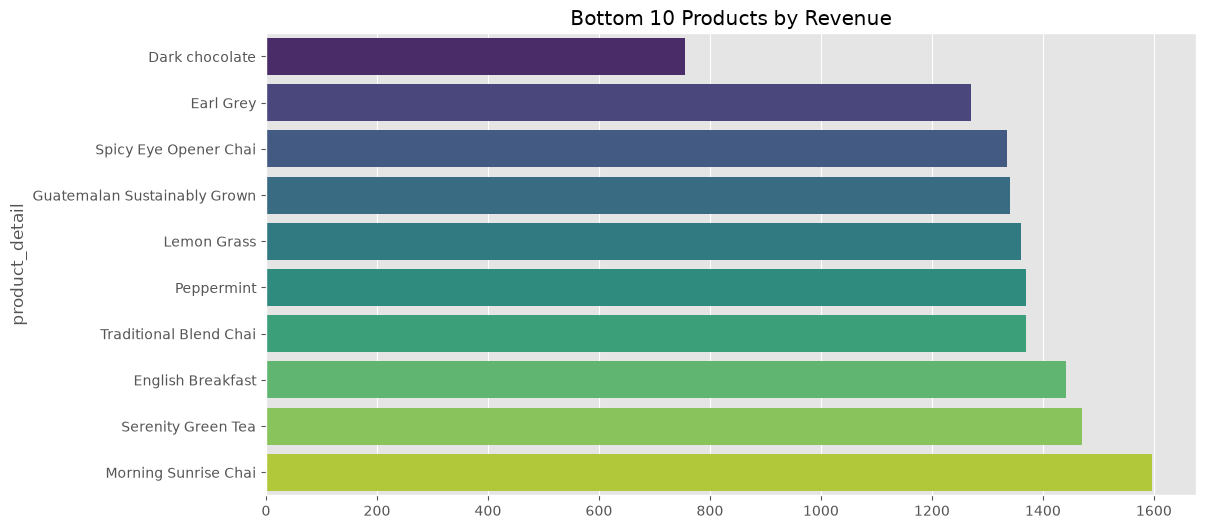

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=bottom_products.values,
    y=bottom_products.index,
    palette="viridis"
)

plt.title("Bottom 10 Products by Revenue")

plt.show()

In [15]:
category = (
    df.groupby("product_category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

category

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: Revenue, dtype: float64

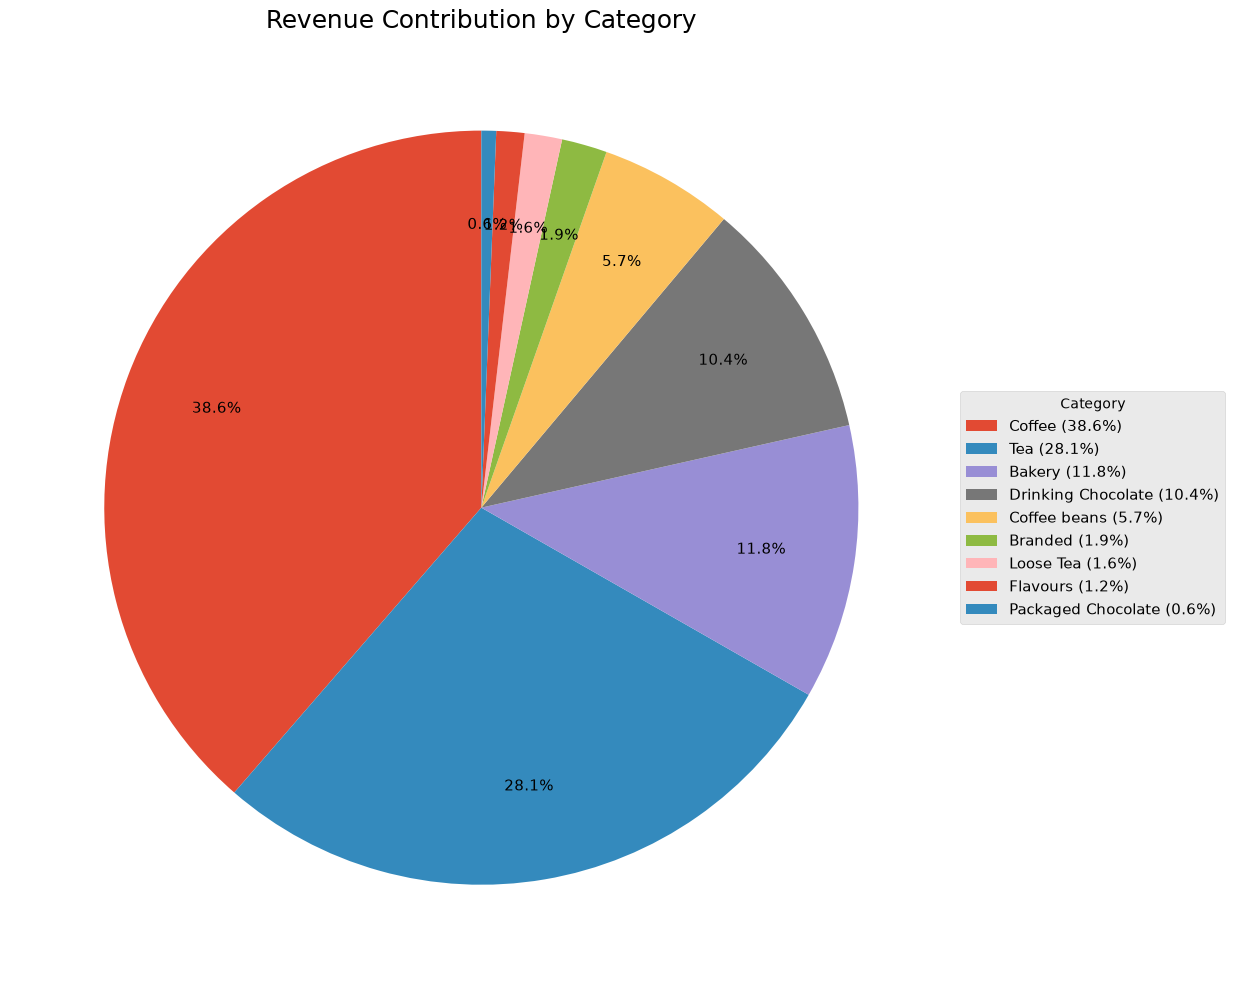

In [16]:
plt.figure(figsize=(12, 10))

percentages = category / category.sum() * 100

legend_labels = [
    f"{cat} ({pct:.1f}%)"
    for cat, pct in zip(category.index, percentages)
]

wedges, texts, autotexts = plt.pie(
    category,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    textprops={"fontsize": 11}
)

plt.legend(
    wedges,
    legend_labels,
    title="Category",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=11
)

plt.title("Revenue Contribution by Category", fontsize=18)
plt.tight_layout()
plt.show()

In [17]:
ptype = (
    df.groupby("product_type")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

ptype.head(15)

product_type
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Brewed herbal tea        47539.50
Premium brewed coffee    38781.15
Organic brewed coffee    37746.50
Scone                    36866.12
Drip coffee              31984.00
Pastry                   25655.99
Brewed Green tea         23852.50
Biscotti                 19793.53
Premium Beans            14583.50
Organic Beans             8509.50
Name: Revenue, dtype: float64

In [18]:
product_revenue = (
    df.groupby("product_detail")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

share = (
    product_revenue /
    product_revenue.sum()
)*100

share.head(15)

product_detail
Sustainably Grown Organic Lg    3.026814
Dark chocolate Lg               3.005957
Latte Rg                        2.734962
Cappuccino Lg                   2.524533
Morning Sunrise Chai Lg         2.487649
Latte                           2.469547
Jamaican Coffee River Lg        2.358466
Sustainably Grown Organic Rg    2.323049
Cappuccino                      2.289241
Brazilian Lg                    2.162168
Ethiopia Lg                     2.117092
Dark chocolate Rg               2.006905
Spicy Eye Opener Chai Lg        1.953658
Ethiopia Rg                     1.885914
Brazilian Rg                    1.882480
Name: Revenue, dtype: float64

In [19]:
scatter = (
    df.groupby("product_detail")
      .agg(
          Revenue=("Revenue","sum"),
          Quantity=("transaction_qty","sum")
      )
)

fig = px.scatter(
    scatter,
    x="Quantity",
    y="Revenue",
    hover_name=scatter.index,
    size="Revenue",
    color="Revenue",
    title="Popularity vs Revenue"
)

fig.show()

In [20]:
store_product = pd.pivot_table(
    df,
    values="Revenue",
    index="store_location",
    columns="product_category",
    aggfunc="sum"
)

store_product

product_category,Bakery,Branded,Coffee,Coffee beans,Drinking Chocolate,Flavours,Loose Tea,Packaged Chocolate,Tea
store_location,,,,,,,,,
Astoria,26599.75,5457.0,89744.30,10219.20,26335.25,1764.8,3194.00,1089.71,67839.90
Hell's Kitchen,27386.95,1942.0,91222.65,18635.10,23586.25,2876.8,4461.35,1698.77,64701.30
Lower Manhattan,28328.94,6208.0,88985.50,11230.95,22494.50,3767.2,3558.25,1619.16,63864.75


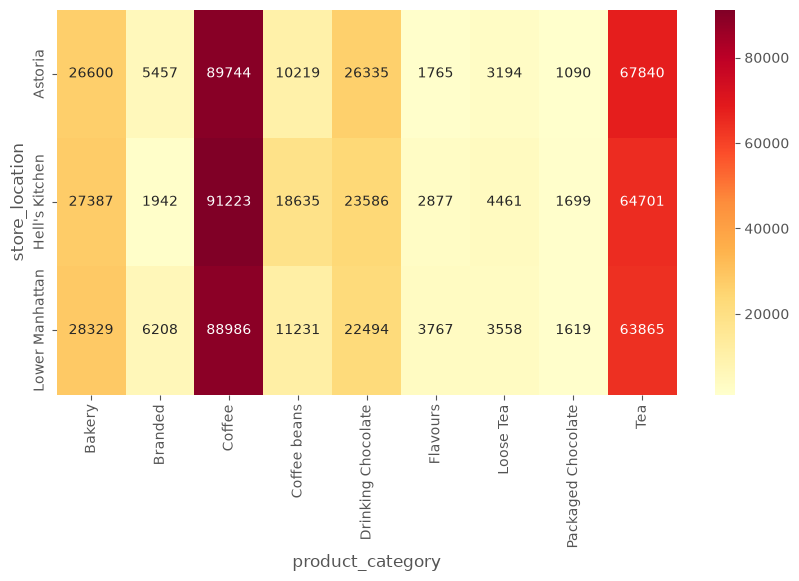

In [21]:
plt.figure(figsize=(10,5))

sns.heatmap(
    store_product,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)

plt.show()

In [22]:
pareto = (
    df.groupby("product_detail")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

pareto_df = pareto.reset_index()

pareto_df.columns = ["Product","Revenue"]

pareto_df["CumRevenue"] = pareto_df["Revenue"].cumsum()

pareto_df["CumPercent"] = (
    pareto_df["CumRevenue"] /
    pareto_df["Revenue"].sum()
)*100
pareto

product_detail
Sustainably Grown Organic Lg    21151.75
Dark chocolate Lg               21006.00
Latte Rg                        19112.25
Cappuccino Lg                   17641.75
Morning Sunrise Chai Lg         17384.00
                                  ...   
Lemon Grass                      1360.40
Guatemalan Sustainably Grown     1340.00
Spicy Eye Opener Chai            1335.90
Earl Grey                        1270.90
Dark chocolate                    755.20
Name: Revenue, Length: 80, dtype: float64

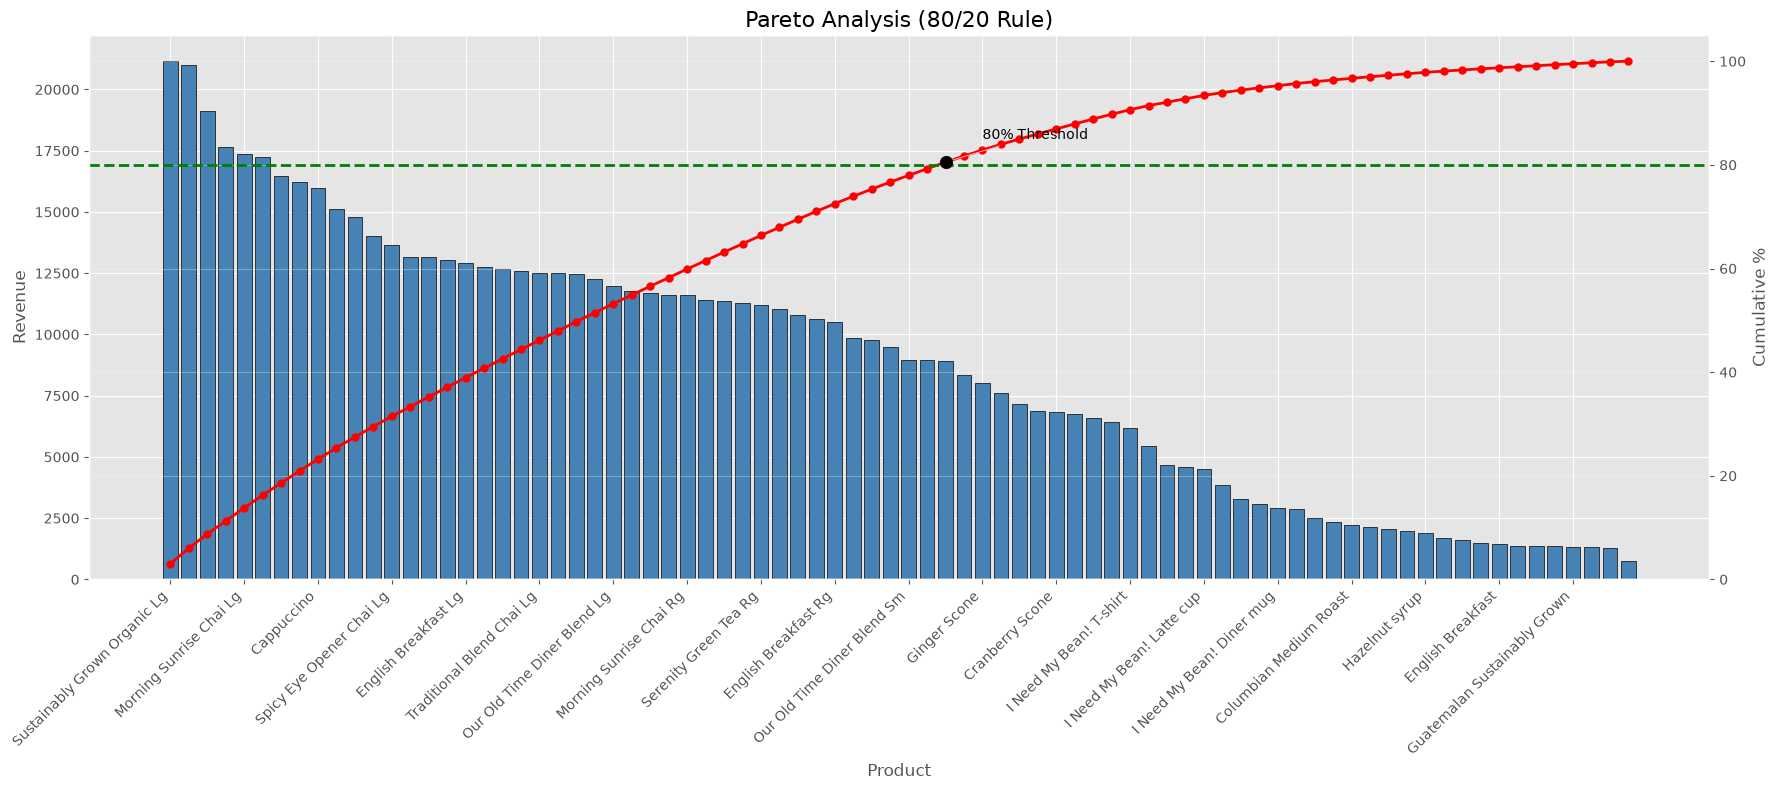

In [24]:
fig, ax = plt.subplots(figsize=(18, 8))

# Bar chart
ax.bar(
    pareto_df["Product"],
    pareto_df["Revenue"],
    color="steelblue",
    edgecolor="black"
)

ax.set_ylabel("Revenue")
ax.set_xlabel("Product")

# Secondary axis
ax2 = ax.twinx()

ax2.plot(
    pareto_df["Product"],
    pareto_df["CumPercent"],
    color="red",
    marker="o",
    linewidth=2,
    markersize=5
)

# 80% reference line
ax2.axhline(y=80, color="green", linestyle="--", linewidth=2)

# Find where cumulative percentage first reaches 80%
idx80 = np.argmax(pareto_df["CumPercent"] >= 80)

ax2.scatter(
    pareto_df["Product"].iloc[idx80],
    pareto_df["CumPercent"].iloc[idx80],
    color="black",
    s=80,
    zorder=5
)

ax2.annotate(
    "80% Threshold",
    xy=(idx80, pareto_df["CumPercent"].iloc[idx80]),
    xytext=(idx80 + 2, 85),
    arrowprops=dict(arrowstyle="->")
)

# Axis formatting
ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 105)

# Show fewer x labels
step = max(1, len(pareto_df) // 20)
ax.set_xticks(range(0, len(pareto_df), step))
ax.set_xticklabels(
    pareto_df["Product"][::step],
    rotation=45,
    ha="right"
)

plt.title("Pareto Analysis (80/20 Rule)", fontsize=16)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

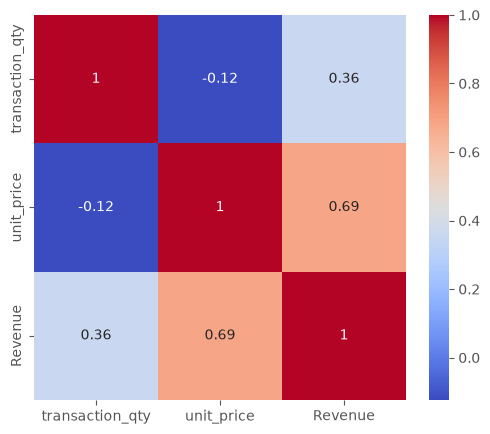

In [ ]:
corr = df[
    ["transaction_qty","unit_price","Revenue"]
].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
print("="*60)

print("EXECUTIVE SUMMARY")

print("="*60)

print(f"Total Revenue : ${df['Revenue'].sum():,.2f}")

print(f"Best Category : {category.idxmax()}")

print(f"Top Product : {top_products.index[0]}")

print(f"Most Popular Product : {popular_products.index[0]}")

print(f"Lowest Product : {bottom_products.index[0]}")

EXECUTIVE SUMMARY
Total Revenue : $698,812.33
Best Category : Coffee
Top Product : Sustainably Grown Organic Lg
Most Popular Product : Earl Grey Rg
Lowest Product : Dark chocolate


In [ ]:
print("1. Focus marketing on top revenue-generating products.")
print("2. Review low-performing products for possible removal or redesign.")
print("3. Increase stock levels for hero products.")
print("4. Reduce inventory allocated to low-demand products.")
print("5. Bundle slow-selling products with popular items.")
print("6. Monitor category revenue concentration to reduce business risk.")
print("7. Use product performance insights to optimize the menu.")


1. Focus marketing on top revenue-generating products.
2. Review low-performing products for possible removal or redesign.
3. Increase stock levels for hero products.
4. Reduce inventory allocated to low-demand products.
5. Bundle slow-selling products with popular items.
6. Monitor category revenue concentration to reduce business risk.
7. Use product performance insights to optimize the menu.
